# ASSIGNMENT 10 — VAE for Compression and Denoising

**Objective:** Use a Variational Autoencoder (VAE) on MNIST for:
1. Data compression
2. Image reconstruction
3. Image denoising
4. Comparing latent dimensions 2, 16 and 32

> The assignment sheet shown to you says **Assignment 9**, but based on your course sequence you are treating this as **Assignment 10**. Keep the title as **ASSIGNMENT 10** in your submission.


## Part A — Compression

MNIST images contain **28 × 28 = 784 pixel values**.

We first use the VAE from your Assignment 8 with a **2-dimensional latent space**.

Compression ratio:

**Compression Ratio = Original size / Latent size**

For latent dimension 2:

**784 / 2 = 392 : 1**


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = transforms.ToTensor()

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

print("Training images:", len(train_data))
print("Test images:", len(test_data))


Device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 45.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.00MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.17MB/s]

Training images: 60000
Test images: 10000


In [2]:
# VAE used in Assignment 8: latent dimension = 2

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim
        self.fc1 = nn.Linear(784, 128)
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.fc2 = nn.Linear(latent_dim, 128)
        self.fc3 = nn.Linear(128, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def train_vae(latent_dim, epochs=10):
    model = VAE(latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, _ in train_loader:
            x = x.view(x.size(0), -1).to(device)

            recon, mu, logvar = model(x)

            recon_loss = F.binary_cross_entropy(recon, x, reduction="sum")
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + kl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_data)
        print(f"Latent {latent_dim} | Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

    return model

vae2 = train_vae(2, epochs=10)


Latent 2 | Epoch 1/10 | Loss: 207.5393
Latent 2 | Epoch 2/10 | Loss: 177.2682
Latent 2 | Epoch 3/10 | Loss: 171.1867
Latent 2 | Epoch 4/10 | Loss: 167.3778
Latent 2 | Epoch 5/10 | Loss: 164.8044
Latent 2 | Epoch 6/10 | Loss: 163.0857
Latent 2 | Epoch 7/10 | Loss: 161.7626
Latent 2 | Epoch 8/10 | Loss: 160.6903
Latent 2 | Epoch 9/10 | Loss: 159.7860
Latent 2 | Epoch 10/10 | Loss: 158.9942


### Part A result

The original MNIST image has **784 values** and the VAE stores its representation using **2 latent values**.

**Compression ratio = 784 / 2 = 392 : 1**


In [3]:
compression_ratio_2 = 784 / 2
print(f"Compression ratio for latent dimension 2: {compression_ratio_2:.1f}:1")


Compression ratio for latent dimension 2: 392.0:1


## Part B — Reconstruction

Select 10 test images, encode them into the latent space, decode them, and calculate the Mean Squared Error (MSE).

MSE measures the average difference between the original and reconstructed pixels. Lower MSE means better reconstruction.


In [4]:
# Select 10 test images
images = torch.stack([test_data[i][0] for i in range(10)]).to(device)
flat_images = images.view(10, -1)

vae2.eval()
with torch.no_grad():
    recon_images, mu, logvar = vae2(flat_images)

mse_each = ((flat_images - recon_images) ** 2).mean(dim=1)
print("MSE for each of 10 images:")
for i, mse in enumerate(mse_each.cpu().numpy(), start=1):
    print(f"Image {i}: {mse:.6f}")

print(f"Average MSE: {mse_each.mean().item():.6f}")


MSE for each of 10 images:
Image 1: 0.027570
Image 2: 0.069715
Image 3: 0.007629
Image 4: 0.038809
Image 5: 0.039016
Image 6: 0.005944
Image 7: 0.053395
Image 8: 0.055877
Image 9: 0.083725
Image 10: 0.029164
Average MSE: 0.041084


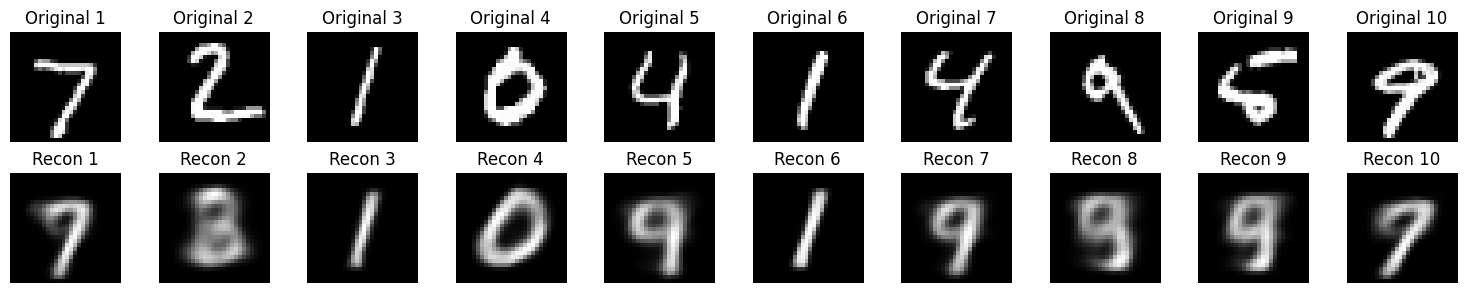

In [5]:
# Save original vs reconstructed comparison
fig, axes = plt.subplots(2, 10, figsize=(15, 3))

for i in range(10):
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Original {i+1}")

    axes[1, i].imshow(recon_images[i].cpu().view(28, 28), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Recon {i+1}")

plt.tight_layout()
plt.savefig("reconstruction_comparison_10_images.png", dpi=200, bbox_inches="tight")
plt.show()


## Part C — Denoising

Add random Gaussian noise to the 10 test images.

The noisy image is passed through the trained VAE. The reconstruction is treated as the **denoised output**.

We compare:
- Original clean image
- Noisy image
- Denoised output


In [6]:
# Add Gaussian noise
noise_std = 0.5
noise = torch.randn_like(flat_images) * noise_std
noisy_images = torch.clamp(flat_images + noise, 0, 1)

# Denoise using the trained VAE
vae2.eval()
with torch.no_grad():
    denoised_images, _, _ = vae2(noisy_images)

# MSE between clean and denoised images
denoise_mse = ((flat_images - denoised_images) ** 2).mean(dim=1)

print("Denoising MSE for each image:")
for i, mse in enumerate(denoise_mse.cpu().numpy(), start=1):
    print(f"Image {i}: {mse:.6f}")

print(f"Average denoising MSE: {denoise_mse.mean().item():.6f}")


Denoising MSE for each image:
Image 1: 0.091406
Image 2: 0.094577
Image 3: 0.061839
Image 4: 0.113377
Image 5: 0.077024
Image 6: 0.089399
Image 7: 0.073061
Image 8: 0.067780
Image 9: 0.104741
Image 10: 0.102296
Average denoising MSE: 0.087550


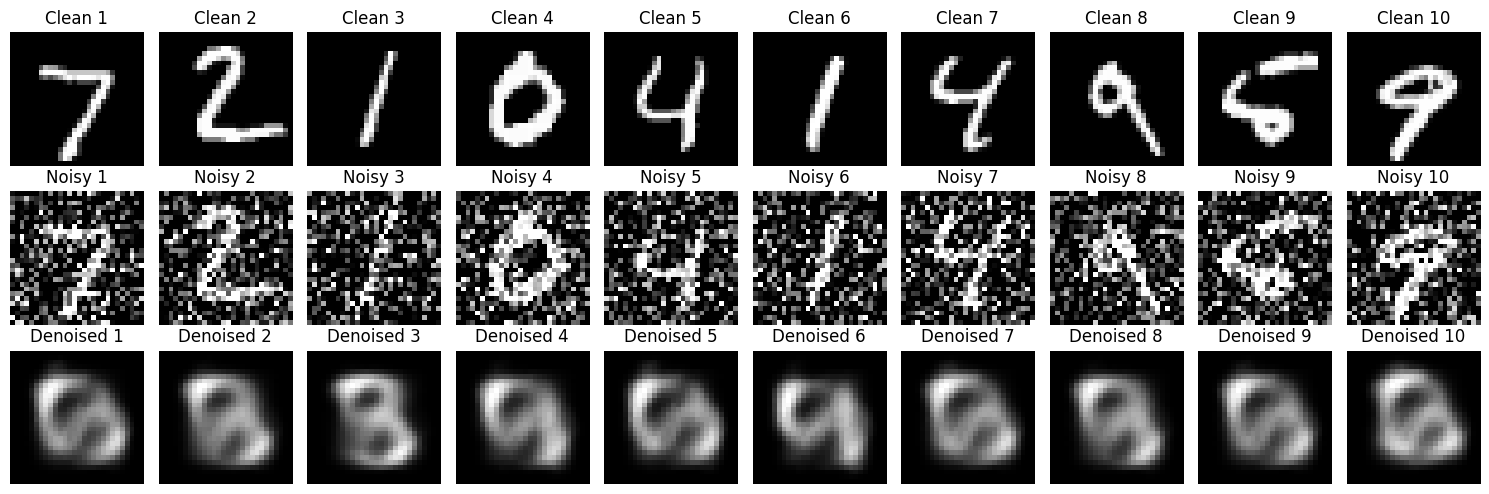

In [7]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for i in range(10):
    axes[0, i].imshow(flat_images[i].cpu().view(28, 28), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Clean {i+1}")

    axes[1, i].imshow(noisy_images[i].cpu().view(28, 28), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Noisy {i+1}")

    axes[2, i].imshow(denoised_images[i].cpu().view(28, 28), cmap="gray")
    axes[2, i].axis("off")
    axes[2, i].set_title(f"Denoised {i+1}")

plt.tight_layout()
plt.savefig("denoising_comparison_10_images.png", dpi=200, bbox_inches="tight")
plt.show()


## Part D — Changing Latent Dimension

Now increase the latent dimension from **2 to 16 and 32**.

A larger latent space gives the VAE more information to store about each image, so reconstruction quality is normally expected to improve, while the compression ratio becomes smaller.


In [8]:
# Train VAEs with latent dimensions 16 and 32
vae16 = train_vae(16, epochs=10)
vae32 = train_vae(32, epochs=10)


Latent 16 | Epoch 1/10 | Loss: 190.2111
Latent 16 | Epoch 2/10 | Loss: 137.6251
Latent 16 | Epoch 3/10 | Loss: 126.1465
Latent 16 | Epoch 4/10 | Loss: 121.4640
Latent 16 | Epoch 5/10 | Loss: 118.7430
Latent 16 | Epoch 6/10 | Loss: 116.9496
Latent 16 | Epoch 7/10 | Loss: 115.5766
Latent 16 | Epoch 8/10 | Loss: 114.4934
Latent 16 | Epoch 9/10 | Loss: 113.7574
Latent 16 | Epoch 10/10 | Loss: 113.1429
Latent 32 | Epoch 1/10 | Loss: 194.0468
Latent 32 | Epoch 2/10 | Loss: 141.2879
Latent 32 | Epoch 3/10 | Loss: 128.9104
Latent 32 | Epoch 4/10 | Loss: 122.2023
Latent 32 | Epoch 5/10 | Loss: 118.3091
Latent 32 | Epoch 6/10 | Loss: 115.9584
Latent 32 | Epoch 7/10 | Loss: 114.4330
Latent 32 | Epoch 8/10 | Loss: 113.3391
Latent 32 | Epoch 9/10 | Loss: 112.4253
Latent 32 | Epoch 10/10 | Loss: 111.7909


In [9]:
def evaluate_model(model, images):
    model.eval()
    flat = images.view(images.size(0), -1)

    with torch.no_grad():
        recon, _, _ = model(flat)

    mse = ((flat - recon) ** 2).mean(dim=1)
    return recon, mse.mean().item()

recon2, mse2 = evaluate_model(vae2, images)
recon16, mse16 = evaluate_model(vae16, images)
recon32, mse32 = evaluate_model(vae32, images)

results = pd.DataFrame({
    "Latent Dimension": [2, 16, 32],
    "Compression Ratio": ["392:1", "49:1", "24.5:1"],
    "Average Reconstruction MSE": [mse2, mse16, mse32],
    "Reconstruction Quality": [
        "Lower detail / acceptable",
        "Better",
        "Best of the three (expected)"
    ]
})

results


,Latent Dimension,Compression Ratio,Average Reconstruction MSE,Reconstruction Quality
0,2,392:1,0.041656,Lower detail / acceptable
1,16,49:1,0.016981,Better
2,32,24.5:1,0.016234,Best of the three (expected)


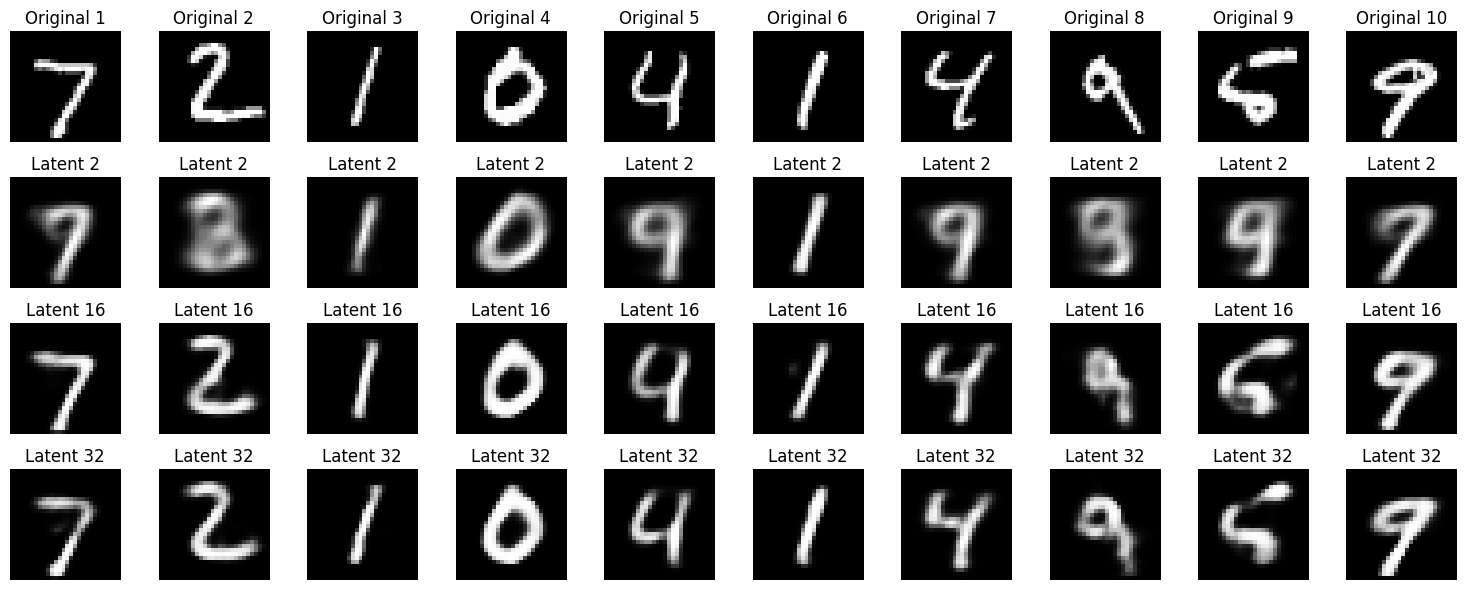

In [10]:
# Visual comparison for latent dimensions 2, 16 and 32
fig, axes = plt.subplots(4, 10, figsize=(15, 6))

for i in range(10):
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Original {i+1}")

    axes[1, i].imshow(recon2[i].cpu().view(28, 28), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("Latent 2")

    axes[2, i].imshow(recon16[i].cpu().view(28, 28), cmap="gray")
    axes[2, i].axis("off")
    axes[2, i].set_title("Latent 16")

    axes[3, i].imshow(recon32[i].cpu().view(28, 28), cmap="gray")
    axes[3, i].axis("off")
    axes[3, i].set_title("Latent 32")

plt.tight_layout()
plt.savefig("latent_dimension_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
